# Driips Opening-Session Backtest

Reproducible end-to-end run of the opening-session stop-run reversion
strategy specified in [`spec/strategy_spec.md`](../spec/strategy_spec.md):
load data → run the gate-chain engines → full metrics → equity curve and
per-trade R distribution.

**Data mode is auto-detected.** If 1-minute CSVs are present in `data/`
(see [`data/README.md`](../data/README.md)) the run is labelled
**REAL** and labelled result artifacts are exported to `results/`;
otherwise deterministic synthetic sessions are generated and the run is
labelled **SYNTHETIC**. Synthetic outputs validate the code path only —
they support no performance claims.

In [1]:
import sys, pathlib
REPO = pathlib.Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_data_dir, make_synthetic
from src.engine import Params, backtest
from src.trend import backtest_trend
from src.metrics import metrics_table, session_returns, split_data, summarize

# ---------------- parameters ----------------
PARAMS = Params()          # defaults sized for NQ; see spec parameter table
MAX_TRADES = 3             # validated trend-continuation cap

# Research-history split (REAL mode). The strategy was developed BEFORE
# the held-out year, on data that is not shipped with this repository;
# the held-out out-of-sample year is Jul 2025 – Jun 2026. Bars after
# OOS_END form a post-OOS forward sample: they also played no part in
# development, but they lie outside the pre-registered held-out year.
# In SYNTHETIC mode these dates are ignored and the last 20% of sessions
# stand in as the held-out block.
OOS_START = "2025-07-01"   # held-out year start (inclusive)
OOS_END = "2026-07-01"     # held-out year end (exclusive)
SYNTH_DAYS = 250
SYNTH_SEED = 7

# validated two-slot categorical palette (blue = net, orange = gross)
C_NET, C_GROSS = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.spines.top": False, "axes.spines.right": False})

In [2]:
df = load_data_dir(str(REPO / "data"))
if df is not None:
    MODE = "REAL"
    mode_note = "vendor 1-minute export(s) found in data/"
else:
    MODE = "SYNTHETIC"
    mode_note = (f"no CSVs in data/ — generated {SYNTH_DAYS} deterministic "
                 f"sessions (seed={SYNTH_SEED}); pipeline validation only, "
                 "NOT a performance claim")
    df = make_synthetic(days=SYNTH_DAYS, seed=SYNTH_SEED)


def cash_sessions(frame):
    """Days with a usable entry window (>= 10 one-minute bars in
    09:30–11:00 NY) — the engine's own skip rule. Futures Sunday stubs
    and holiday half-days therefore don't pad the per-session return
    series with structural zeros."""
    win = frame.between_time(PARAMS.entry_start, PARAMS.entry_end)
    counts = win.groupby(win.index.normalize()).size()
    return counts[counts >= 10].index.sort_values()


sessions_all = cash_sessions(df)
print("=" * 68)
print(f"MODE: {MODE}  ({mode_note})")
print("=" * 68)
print(f"bars: {len(df):,}   usable cash sessions: {len(sessions_all)}   "
      f"data period: {sessions_all[0].date()} → {sessions_all[-1].date()}")

MODE: REAL  (vendor 1-minute export(s) found in data/)
bars: 391,263   usable cash sessions: 285   data period: 2025-07-04 → 2026-08-11


## In-sample / out-of-sample split

The development (in-sample) period is everything before `OOS_START`; the
held-out (out-of-sample) year is `[OOS_START, OOS_END)` and was not
touched during development; anything after `OOS_END` is a post-OOS
forward sample. A REAL run only covers what the local exports cover —
this repository's reference exports begin **at** the held-out year, so
the development period is not recomputable here and the tables report
the OOS and forward segments only. In synthetic mode the explicit dates
are ignored and the last 20% of sessions stand in as the held-out block
so the split machinery always runs.

In [3]:
if MODE == "REAL":
    oos_start = pd.Timestamp(OOS_START).tz_localize(df.index.tz)
    oos_end = pd.Timestamp(OOS_END).tz_localize(df.index.tz)
else:
    oos_start = sessions_all[int(len(sessions_all) * 0.8)]
    oos_end = None

df_is, rest = split_data(df, oos_start)
if oos_end is not None:
    df_oos, df_fwd = split_data(rest, oos_end)
else:
    df_oos, df_fwd = rest, rest.iloc[0:0]

NAMES = {"IS": "development (in-sample)",
         "OOS": "held-out year (out-of-sample)",
         "FWD": "post-OOS forward sample"}
segments = []   # (label, bar frame, session index) — only non-empty ones
for label, frame in [("IS", df_is), ("OOS", df_oos), ("FWD", df_fwd)]:
    sess = cash_sessions(frame)
    if len(sess):
        segments.append((label, frame, sess))

for label, frame, sess in segments:
    print(f"{NAMES[label]:33s} {sess[0].date()} → {sess[-1].date()}  "
          f"({len(sess)} sessions)")
if not any(label == "IS" for label, _, _ in segments):
    print(f"{NAMES['IS']:33s} predates the shipped exports (the strategy")
    print(f"{'':33s} was developed before the held-out year on data")
    print(f"{'':33s} not included here) — IS figures not recomputable.")

held-out year (out-of-sample)     2025-07-04 → 2026-06-30  (255 sessions)
post-OOS forward sample           2026-07-01 → 2026-08-11  (30 sessions)
development (in-sample)           predates the shipped exports (the strategy
                                  was developed before the held-out year on data
                                  not included here) — IS figures not recomputable.


In [4]:
runs, frames = [], {}
for label, frame, sess in segments:
    t_trend, _ = backtest_trend(frame, PARAMS, MAX_TRADES)
    t_base, _ = backtest(frame, PARAMS, max_trades=MAX_TRADES)
    frames[("trend", label)] = t_trend
    frames[("base", label)] = t_base
    runs.append(summarize(t_trend, sess, f"trend {label}"))
    runs.append(summarize(t_base, sess, f"base {label}"))

COSTS = (f"{PARAMS.commission_pts} pts commission + {PARAMS.slippage_pts} pts "
         "slippage per round turn, deducted in R")
print(f"[{MODE}] cost assumptions: {COSTS}.")
print(f"[{MODE}] gross figures are before costs, net after. Trade-level")
print("statistics lead the table; the R-unit Sharpe rows follow (full-period,")
print("unconditional: flat sessions count as 0), with the traded-days-only")
print("figure labelled CONDITIONAL and shown last — see the Sharpe note below.")
mt = metrics_table(runs)
mt

[REAL] cost assumptions: 0.225 pts commission + 0.5 pts slippage per round turn, deducted in R.
[REAL] gross figures are before costs, net after. Trade-level
statistics lead the table; the R-unit Sharpe rows follow (full-period,
unconditional: flat sessions count as 0), with the traded-days-only
figure labelled CONDITIONAL and shown last — see the Sharpe note below.


label,trend OOS,base OOS,trend FWD,base FWD
sessions,255.000,255.000,30.000,30.00
trades,231.000,212.000,28.000,24.00
hit_rate_pct,75.800,74.500,78.600,75.00
total_R_gross,292.950,278.490,34.670,32.32
total_R_net,277.320,263.800,33.400,31.21
avg_R_net_per_trade,1.201,1.244,1.193,1.30
max_drawdown_R,-2.800,-6.340,-3.140,-2.09
max_drawdown_duration_sessions,10.000,16.000,3.000,3.00
pct_sessions_with_exposure,75.300,75.300,73.300,73.30
R_unit_sharpe_annualized (unconditional),6.750,7.520,7.350,7.79


### A note on the Sharpe figure

The Sharpe rows above are computed on per-session risk-unit (R) returns
of a single intraday strategy whose scale-out and breakeven-runner
mechanics structurally suppress losing sessions. That makes the figure
NOT comparable to portfolio-level Sharpe ratios on dollar returns —
readers should weight the trade-level statistics and the drawdown
figures more heavily. The traded-days-only Sharpe is conditional on
being invested and is shown last, labelled.

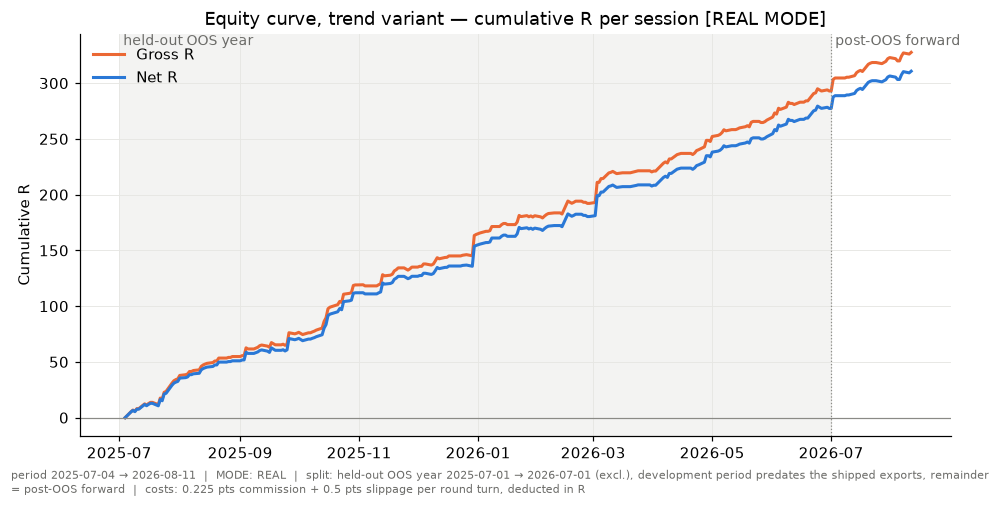

In [5]:
# Equity curve — trend-continuation variant (validated configuration),
# cumulative R per session over the full data period, gross and net.
t_full = pd.concat([frames[("trend", label)] for label, _, _ in segments],
                   ignore_index=True)
eq_net = session_returns(t_full, sessions_all, "r").cumsum()
eq_gross = session_returns(t_full, sessions_all, "r_gross").cumsum()

PERIOD = f"{sessions_all[0].date()} → {sessions_all[-1].date()}"
STAMP = (f"period {PERIOD}  |  MODE: {MODE}  |  split: held-out OOS year "
         f"{OOS_START} → {OOS_END} (excl.), development period predates the "
         f"shipped exports, remainder = post-OOS forward  |  costs: {COSTS}"
         if MODE == "REAL" else
         f"period {PERIOD}  |  MODE: {MODE} (pipeline validation only)  |  "
         f"costs: {COSTS}")

oos_x = pd.Timestamp(oos_start).tz_localize(None)
fwd_x = pd.Timestamp(oos_end).tz_localize(None) if oos_end is not None else None

fig_eq, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(eq_gross.index, eq_gross.values, color=C_GROSS, lw=2, label="Gross R")
ax.plot(eq_net.index, eq_net.values, color=C_NET, lw=2, label="Net R")
span_end = fwd_x if fwd_x is not None else eq_net.index[-1]
ax.axvspan(oos_x, span_end, color="#8a8a86", alpha=0.10, lw=0)
ax.axhline(0, color="#8a8a86", lw=0.8)
ax.text(oos_x, ax.get_ylim()[1], " held-out OOS year", va="top",
        color="#6b6b68", fontsize=9)
if fwd_x is not None and fwd_x < eq_net.index[-1]:
    ax.axvline(fwd_x, color="#8a8a86", lw=0.8, ls=":")
    ax.text(fwd_x, ax.get_ylim()[1], " post-OOS forward", va="top",
            color="#6b6b68", fontsize=9)
ax.set_title("Equity curve, trend variant — cumulative R per session "
             f"[{MODE} MODE]")
ax.set_ylabel("Cumulative R")
ax.legend(frameon=False, loc="upper left")
fig_eq.text(0.01, -0.03, STAMP, fontsize=7, color="#6b6b68", wrap=True)
plt.tight_layout(); plt.show()

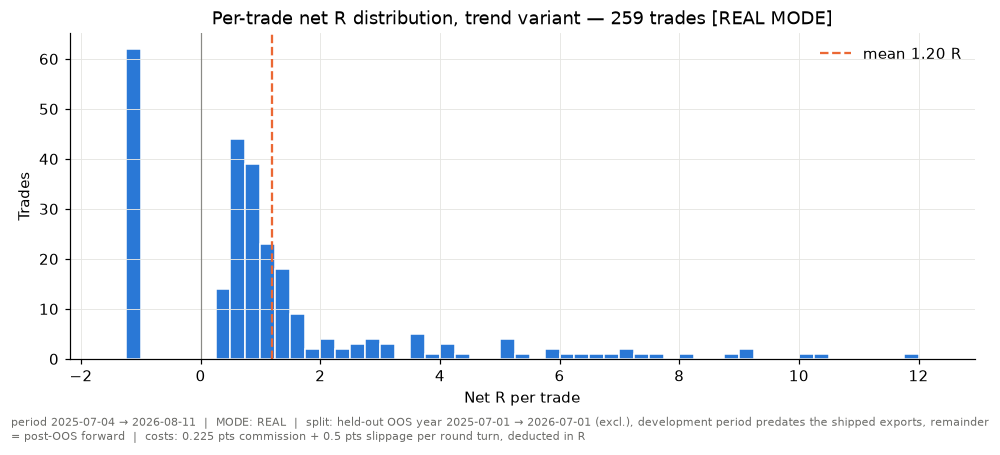

[REAL] every figure above was produced in REAL mode.


In [6]:
# Per-trade R distribution (net, after costs) — trend variant, full period.
fig_rd, ax = plt.subplots(figsize=(9, 3.9))
r = t_full["r"]
bins = np.arange(np.floor(r.min() * 2) / 2, np.ceil(r.max() * 2) / 2 + 0.5, 0.25)
ax.hist(r, bins=bins, color=C_NET, edgecolor="white", linewidth=1)
ax.axvline(0, color="#8a8a86", lw=0.8)
ax.axvline(r.mean(), color=C_GROSS, lw=1.5, ls="--",
           label=f"mean {r.mean():.2f} R")
ax.set_title(f"Per-trade net R distribution, trend variant — "
             f"{len(r)} trades [{MODE} MODE]")
ax.set_xlabel("Net R per trade"); ax.set_ylabel("Trades")
ax.legend(frameon=False)
fig_rd.text(0.01, -0.04, STAMP, fontsize=7, color="#6b6b68", wrap=True)
plt.tight_layout(); plt.show()

print(f"[{MODE}] every figure above was produced in {MODE} mode.")
if MODE == "SYNTHETIC":
    print("SYNTHETIC results are pipeline validation only — the generator")
    print("plants the very structure the engine hunts, so profitability or")
    print("unprofitability here says nothing about the strategy on markets.")

In [7]:
# Export labelled artifacts to results/ — REAL mode only. Synthetic
# outputs never leave the notebook.
if MODE == "REAL":
    RES = REPO / "results"
    mt.to_csv(RES / "metrics_real.csv")

    body = mt.astype(str)
    fig_t, ax = plt.subplots(figsize=(9.5, 0.42 * len(body) + 2.2))
    ax.axis("off")
    tbl = ax.table(cellText=body.values, rowLabels=body.index,
                   colLabels=body.columns, loc="center",
                   cellLoc="center", rowLoc="right")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.4)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("#e6e6e3")
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2ef")
    ax.set_title("Driips opening-session backtest — metrics", pad=18)
    fig_t.text(0.01, 0.005, STAMP, fontsize=7, color="#6b6b68", wrap=True)
    fig_t.savefig(RES / "metrics_real.png", dpi=200, bbox_inches="tight")
    plt.close(fig_t)

    fig_eq.savefig(RES / "equity_curve_real.png", dpi=200, bbox_inches="tight")
    fig_rd.savefig(RES / "r_distribution_real.png", dpi=200, bbox_inches="tight")
    for f in ("metrics_real.csv", "metrics_real.png",
              "equity_curve_real.png", "r_distribution_real.png"):
        print(f"wrote results/{f}")
    print(f"label on every artifact: {STAMP}")
else:
    print("[SYNTHETIC] no artifacts exported — results/ receives REAL runs only.")

wrote results/metrics_real.csv
wrote results/metrics_real.png
wrote results/equity_curve_real.png
wrote results/r_distribution_real.png
label on every artifact: period 2025-07-04 → 2026-08-11  |  MODE: REAL  |  split: held-out OOS year 2025-07-01 → 2026-07-01 (excl.), development period predates the shipped exports, remainder = post-OOS forward  |  costs: 0.225 pts commission + 0.5 pts slippage per round turn, deducted in R


## Limitations

- **Sample size.** A few trades per day at most, many flat sessions; hit
  rate and expectancy carry wide confidence intervals at these counts.
- **Single-instrument concentration.** Evidence from one index future
  only; no transfer claim to other instruments.
- **Regime dependence.** The edge is conditional on how the 09:30 auction
  has traded in the tested window; opening-liquidity regime changes can
  degrade it without warning.
- **Slippage uncertainty.** Zone-midpoint fills with a flat slippage
  allowance; real limit-order queue position and stop slippage in fast
  markets are worse than any flat assumption on some days.
- **Capacity.** The strategy trades moments of thin, one-sided depth by
  design; nothing here speaks to execution at size.

As corroboration of the cost and fill assumptions: the held-out-year
backtest (+277.3R across 231 trades) agrees within about 4% with the
strategy's automated live execution over the same year (approximately
+274R across ~222 trades, in R terms).